In [57]:
import sys
from math import radians, sin, cos, sqrt, atan2
import geopandas as gpd
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import requests
import time
from pathlib import Path
sys.path.append(str(Path("..") / "src"))
from data_loader import load_data # type: ignore
from modeling.evaluation import calculate_regression_metrics, create_prediction_frame # type: ignore
from modeling.models import get_model # type: ignore

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.cluster import KMeans
from sklearn.neighbors import NearestNeighbors

sns.set_theme(style="darkgrid")
FIGSIZE = (12, 7)
DPI = 300

In [58]:
data = load_data()
train, val = data["train"]["listings"], data["val"]["listings"]
y_train, y_val = train["log_price"], val["log_price"]

### Random forest on basic spatial features

In [59]:
# raw coordinates only
model_a = get_model("random_forest")
model_a.fit(train[["latitude", "longitude"]], y_train)
pred_a = model_a.predict(val[["latitude", "longitude"]])
print("Raw coords only:", calculate_regression_metrics(y_val, pred_a, target="log_price"))

Raw coords only: {'mae': 0.47061784374619675, 'rmse': 0.670300546140432, 'r2': 0.06143658943934227, 'mae_eur': 99.48563989675053, 'rmse_eur': 610.9820060769133}


In [60]:
# + neighborhood_group
preprocessor = ColumnTransformer([("cat", OneHotEncoder(handle_unknown="ignore"), ["neighborhood_group"])], remainder="passthrough")
model_b = Pipeline([("preprocess", preprocessor), ("model", get_model("random_forest"))])
cols = ["latitude", "longitude", "neighborhood_group"]
model_b.fit(train[cols], y_train)
pred_b = model_b.predict(val[cols])
print("+ neighborhood_group:", calculate_regression_metrics(y_val, pred_b, target="log_price"))

+ neighborhood_group: {'mae': 0.47035228836599097, 'rmse': 0.6708433037414198, 'r2': 0.059916021779238826, 'mae_eur': 99.42413349765975, 'rmse_eur': 610.9905660582235}


In [61]:
# Check for overfitting on train
train_pred = model_a.predict(train[["latitude", "longitude"]])
print("train:", calculate_regression_metrics(y_train, train_pred, target="log_price"))

train: {'mae': 0.22587241205816747, 'rmse': 0.3007362721583193, 'r2': 0.7358719975174357, 'mae_eur': 29.12758534796758, 'rmse_eur': 49.736218359754545}


-> Overfitting and the + neighborhood_group made r2 even worse

In [62]:
# Find which preds are exploding
pred_frame = create_prediction_frame(val["listing_id"], y_val, pred_a, target="log_price")
pred_frame.sort_values("absolute_error_eur", ascending=False).head(10)

,listing_id,y_true,y_pred,residual,absolute_error,true_price_eur,predicted_price_eur,absolute_error_eur
563,38585015,9.210340,3.975774,5.234567,5.234567,9999.0,52.291334,9946.708666
384,1234480152776356938,9.210340,4.000747,5.209593,5.209593,9999.0,53.638946,9945.361054
483,20109066,9.210340,4.460572,4.749768,4.749768,9999.0,85.536990,9913.463010
116,1234474294833419521,9.211140,4.597221,4.613919,4.613919,10007.0,98.208277,9908.791723
273,1477047577783123029,9.005896,4.540761,4.465135,4.465135,8150.0,92.762118,8057.237882
790,1234473450946805436,8.987822,5.064332,3.923490,3.923490,8004.0,157.274634,7846.725366
15,7807397,8.140316,4.419483,3.720833,3.720833,3429.0,82.053309,3346.946691
1302,41787739,7.745436,5.219978,2.525458,2.525458,2310.0,183.930116,2126.069884
48,29022524,7.437206,5.122607,2.314599,2.314599,1697.0,166.772244,1530.227756
151,16799799,7.159292,5.245203,1.914089,1.914089,1285.0,188.654261,1096.345739


-> Predictions are off because validation has extreme prices, that the modes hasnt seen, because train was trimmed, and val not for data leakage purposes

### Testing out tuning

In [63]:
def make_rf(random_seed=42):
    return RandomForestRegressor(n_estimators=300, max_depth=10, min_samples_leaf=10, max_features=1.0,random_state=random_seed, n_jobs=-1)

In [64]:
# raw coordinates only
model_a = make_rf()
model_a.fit(train[["latitude", "longitude"]], y_train)
pred_a = model_a.predict(val[["latitude", "longitude"]])
print("Raw coords only:", calculate_regression_metrics(y_val, pred_a, target="log_price"))

Raw coords only: {'mae': 0.46853462418050945, 'rmse': 0.6597383492423733, 'r2': 0.09078219486211037, 'mae_eur': 99.407129130365, 'rmse_eur': 610.5492705645477}


In [65]:
# + neighborhood_group
preprocessor = ColumnTransformer([("cat", OneHotEncoder(handle_unknown="ignore"), ["neighborhood_group"])], remainder="passthrough")
model_b = Pipeline([("preprocess", preprocessor), ("model", make_rf())])
cols = ["latitude", "longitude", "neighborhood_group"]
model_b.fit(train[cols], y_train)
pred_b = model_b.predict(val[cols])
print("+ neighborhood_group:", calculate_regression_metrics(y_val, pred_b, target="log_price"))

+ neighborhood_group: {'mae': 0.4688835460753898, 'rmse': 0.6581685608156016, 'r2': 0.09510385222055029, 'mae_eur': 99.4105748653466, 'rmse_eur': 610.4758339084444}


In [66]:
# Check for overfitting
train_pred = model_a.predict(train[["latitude", "longitude"]])
print("train:", calculate_regression_metrics(y_train, train_pred, target="log_price"))

train: {'mae': 0.3911416705202023, 'rmse': 0.4986295987241755, 'r2': 0.273895827655503, 'mae_eur': 47.757661709847426, 'rmse_eur': 72.67758795185067}


-> much better, more features add real precision now. the raw EUR misses stayed the same, but thats a problem with dataset. overfitting is reduced

Spatial baseline (Random Forest, max_depth=10, min_samples_leaf=10, n_estimators=300):

- Raw lat/long only:              val R² = 0.091, val RMSE (log) = 0.660
- neighborhood_group:           val R² = 0.095, val RMSE (log) = 0.658
  -> neighborhood adds some signal beyond raw coordinates

- Train R² = 0.274 vs val R² = 0.091 -> reasonable, not overfit
  (initial gave train R² = 0.736, val R² = 0.061 -> overfit,
   likely memorizing the 500 exact same coordinate listings)

- Euro RMSE (610 EUR) is inflated by 10 untrimmed high-price val listings (9999 EUR) ->
  data_loader.py only trims outliers from train, not val/test, so this is expected

### Engineering distance to center

In [67]:
CENTER_LAT, CENTER_LON = 52.520833, 13.409444  # Berlin TV tower

def haversine(lat, lon, lat0=CENTER_LAT, lon0=CENTER_LON):
    R = 6371
    lat, lon, lat0, lon0 = map(radians, [lat, lon, lat0, lon0])
    dlat, dlon = lat - lat0, lon - lon0
    a = sin(dlat / 2) ** 2 + cos(lat0) * cos(lat) * sin(dlon / 2) ** 2
    return 2 * R * atan2(sqrt(a), sqrt(1 - a))

In [68]:
for df in [train, val]:
    df["dist_to_center"] = df.apply(lambda r: haversine(r["latitude"], r["longitude"]), axis=1)

In [69]:
# distance alone
model_c = make_rf()
model_c.fit(train[["dist_to_center"]], y_train)
pred_c = model_c.predict(val[["dist_to_center"]])
print("distance only:", calculate_regression_metrics(y_val, pred_c, target="log_price"))

distance only: {'mae': 0.4878211340084515, 'rmse': 0.6773334830985918, 'r2': 0.04163804939489335, 'mae_eur': 101.38124031136286, 'rmse_eur': 610.4719878706536}


In [70]:
# coords + distance
model_d = make_rf()
cols_d = ["latitude", "longitude", "dist_to_center"]
model_d.fit(train[cols_d], y_train)
pred_d = model_d.predict(val[cols_d])
print("coords + distance:", calculate_regression_metrics(y_val, pred_d, target="log_price"))

coords + distance: {'mae': 0.4678761836403713, 'rmse': 0.6575211975418276, 'r2': 0.09688305735982483, 'mae_eur': 99.10239597037626, 'rmse_eur': 610.360224637459}


In [71]:
#coords + distance + neighborhood_group
model_e = ColumnTransformer([("cat", OneHotEncoder(handle_unknown="ignore"), ["neighborhood_group"])], remainder="passthrough")
model_e = Pipeline([("preprocess", model_e), ("model", make_rf())])
cols_e = ["latitude", "longitude", "dist_to_center", "neighborhood_group"]
model_e.fit(train[cols_e], y_train)
pred_e = model_e.predict(val[cols_e])
print("+ neighborhood_group:", calculate_regression_metrics(y_val, pred_e, target="log_price"))

+ neighborhood_group: {'mae': 0.46763411569054253, 'rmse': 0.656801923570278, 'r2': 0.09885784757008986, 'mae_eur': 99.07561061622255, 'rmse_eur': 610.2862700894156}


-> distance alone is a weak feature, because it compresses 2d into one single number, there is distance, but no direction. coord + distance adds no new information, but maybe some shortcuts for the model, so it improves a little. all three features deliver the best result yet

### KMeans

In [72]:
# clustering measures raw distance, so it needs meters, not degrees
def to_metric_xy(df):
    gdf = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(df["longitude"], df["latitude"]), crs="EPSG:4326").to_crs("EPSG:25833")
    return np.column_stack([gdf.geometry.x.values, gdf.geometry.y.values]) # type: ignore

In [73]:
train_xy = to_metric_xy(train)
val_xy = to_metric_xy(val)

In [74]:
# Fit on train only
# n init runs it 10 times with different starting positions and keeps the best ones
kmeans = KMeans(n_clusters=7, random_state=42, n_init=10)
train["cluster"] = kmeans.fit_predict(train_xy).astype(str)
val["cluster"] = kmeans.predict(val_xy).astype(str)

# Distance to the nearest centroid, transform gives distance to all centroids, so take min
train["dist_to_cluster"] = kmeans.transform(train_xy).min(axis=1)
val["dist_to_cluster"] = kmeans.transform(val_xy).min(axis=1)

preprocessor_f = ColumnTransformer([("cat", OneHotEncoder(handle_unknown="ignore"), ["neighborhood_group", "cluster"])], remainder="passthrough")
model_f = Pipeline([("preprocess", preprocessor_f), ("model", make_rf())])
cols_f = ["latitude", "longitude", "dist_to_center", "neighborhood_group", "cluster", "dist_to_cluster"]
model_f.fit(train[cols_f], y_train)
pred_f = model_f.predict(val[cols_f])
print("+ cluster (k=8):", calculate_regression_metrics(y_val, pred_f, target="log_price"))

+ cluster (k=8): {'mae': 0.4658076901824359, 'rmse': 0.6559656121609513, 'r2': 0.10115125028798555, 'mae_eur': 98.85510212494427, 'rmse_eur': 610.3141795362777}


In [75]:
for k in range(2, 20):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    train["cluster"] = km.fit_predict(train_xy).astype(str)
    val["cluster"] = km.predict(val_xy).astype(str)
    train["dist_to_cluster"] = km.transform(train_xy).min(axis=1)
    val["dist_to_cluster"] = km.transform(val_xy).min(axis=1)

    pre = ColumnTransformer([("cat", OneHotEncoder(handle_unknown="ignore"), ["neighborhood_group", "cluster"])], remainder="passthrough")
    m = Pipeline([("preprocess", pre), ("model", make_rf())])
    m.fit(train[cols_f], y_train)
    pred = m.predict(val[cols_f])
    print(f"k={k}:", calculate_regression_metrics(y_val, pred, target="log_price"))

k=2: {'mae': 0.4665956879769264, 'rmse': 0.6556077826213522, 'r2': 0.10213162761996097, 'mae_eur': 98.95749658298436, 'rmse_eur': 610.3228815964361}
k=3: {'mae': 0.4669341644247042, 'rmse': 0.6562214045201786, 'r2': 0.1004501053921234, 'mae_eur': 98.9593130221322, 'rmse_eur': 610.2329145387806}
k=4: {'mae': 0.4667291074945047, 'rmse': 0.6556736380960989, 'r2': 0.10195123770008119, 'mae_eur': 98.9991912765666, 'rmse_eur': 610.344352460804}
k=5: {'mae': 0.46657962993450725, 'rmse': 0.6562616745605636, 'r2': 0.1003396974662818, 'mae_eur': 98.95046573700081, 'rmse_eur': 610.4304736909887}
k=6: {'mae': 0.4670695211017941, 'rmse': 0.6559893746709085, 'r2': 0.10108612708995601, 'mae_eur': 98.99805996596604, 'rmse_eur': 610.416917136441}
k=7: {'mae': 0.4658076901824359, 'rmse': 0.6559656121609512, 'r2': 0.10115125028798577, 'mae_eur': 98.85510212494427, 'rmse_eur': 610.3141795362777}
k=8: {'mae': 0.46804028011804283, 'rmse': 0.6582355170213738, 'r2': 0.09491973071082394, 'mae_eur': 99.11734486

-> clustering delivers just a slight improvement on the prediction. some of the more better ones are probably just lucky clustering. locking in k=10 as a nice mid sized value for now. all the features were derived from lat/long, and there was only a slight improvement, which suggests, that the raw coordinates already deliver a very big chunk of information

In [76]:
GEOJSON_PATH = Path("../data/clean/neighbourhoods.geojson")
OUTPUT_DIR = Path("../output/spatial")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

def save_fig(fig, name):
    path = OUTPUT_DIR / f"{name}.png"
    fig.savefig(path, dpi=DPI, bbox_inches="tight")
    print(f"Saved: {path}")

neighborhoods = gpd.read_file(GEOJSON_PATH)
neighborhoods = neighborhoods[neighborhoods["neighborhood"].notna()].reset_index(drop=True)
groups_metric = neighborhoods.dissolve(by="neighborhood_group", as_index=False).to_crs("EPSG:25833")

train_xy_gdf = gpd.GeoDataFrame(train, geometry=gpd.points_from_xy(train["longitude"], train["latitude"]), crs="EPSG:4326").to_crs("EPSG:25833")
train_xy = np.column_stack([train_xy_gdf.geometry.x, train_xy_gdf.geometry.y])

Saved: ../output/spatial/cluster_map_k10.png


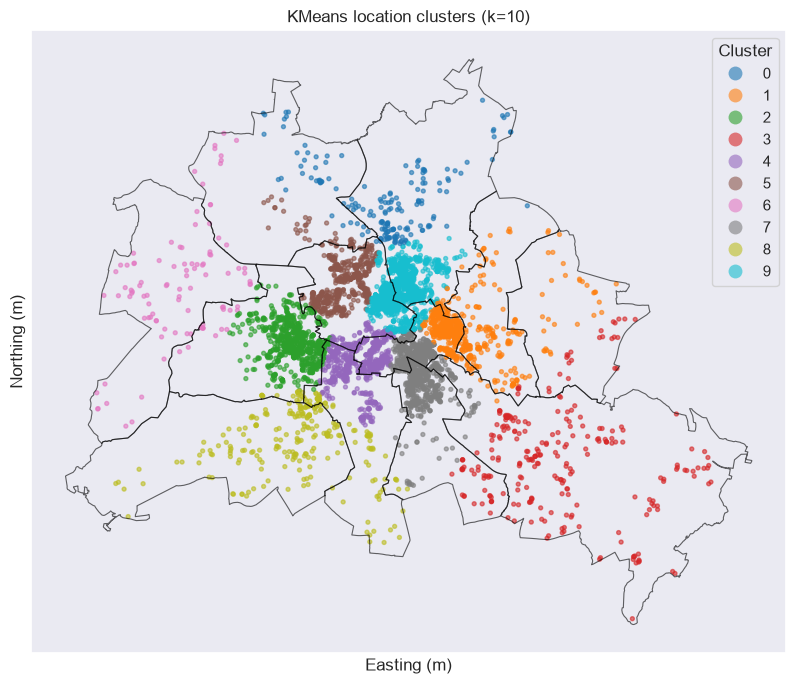

In [77]:
kmeans = KMeans(n_clusters=10, random_state=42, n_init=10)
train["cluster"] = kmeans.fit_predict(train_xy).astype(str)
cluster_pts = gpd.GeoDataFrame(train, geometry=gpd.points_from_xy(train["longitude"], train["latitude"]), crs="EPSG:4326").to_crs("EPSG:25833")
fig, ax = plt.subplots(figsize=FIGSIZE)
groups_metric.boundary.plot(ax=ax, color="black", linewidth=0.8, alpha=0.6)

cluster_pts.plot(column="cluster", categorical=True, cmap="tab10", markersize=8, alpha=0.6, legend=True, legend_kwds={"title": "Cluster"}, ax=ax)

ax.set_aspect("equal"); ax.grid(False)
ax.set_xticks([]); ax.set_yticks([])
ax.set_xlabel("Easting (m)"); ax.set_ylabel("Northing (m)")
ax.set_title("KMeans location clusters (k=10)")

plt.tight_layout()
save_fig(fig, "cluster_map_k10")
plt.show()

### KNN smoothing

In [78]:
for k in range(2, 20):
	nn = NearestNeighbors()
	nn.fit(train_xy)
	train_log_prices = train["log_price"].values


	# K+1 neighbors, drop the exact self-match, average the remaining K
	train_idx = nn.kneighbors(train_xy, n_neighbors=k + 1, return_distance=False)
	train["knn_price_smooth"] = [train_log_prices[[j for j in row if j != i][:k]].mean() for i, row in enumerate(train_idx)]


	#  K directly, val points were never in the fitted set, so no self-match
	val_idx = nn.kneighbors(val_xy, n_neighbors=k, return_distance=False)
	val["knn_price_smooth"] = train_log_prices[val_idx].mean(axis=1)


	km = KMeans(n_clusters=10, random_state=42, n_init=10)
	train["cluster"] = km.fit_predict(train_xy).astype(str)
	val["cluster"] = km.predict(val_xy).astype(str)
	train["dist_to_cluster"] = km.transform(train_xy).min(axis=1)
	val["dist_to_cluster"] = km.transform(val_xy).min(axis=1)

	cols_g = ["latitude", "longitude", "dist_to_center", "neighborhood_group", "cluster", "dist_to_cluster", "knn_price_smooth"]
	pre_g = ColumnTransformer([("cat", OneHotEncoder(handle_unknown="ignore"), ["neighborhood_group", "cluster"])], remainder="passthrough")
	model_g = Pipeline([("preprocess", pre_g), ("model", make_rf())])
	model_g.fit(train[cols_g], y_train)
	pred_g = model_g.predict(val[cols_g])
	print("+ knn_price_smooth:", calculate_regression_metrics(y_val, pred_g, target="log_price"))

+ knn_price_smooth: {'mae': 0.4664514556364361, 'rmse': 0.6620404115031977, 'r2': 0.08442595456595792, 'mae_eur': 99.0665422643173, 'rmse_eur': 610.973189323395}
+ knn_price_smooth: {'mae': 0.4679113007598154, 'rmse': 0.6632354806944355, 'r2': 0.08111751031217684, 'mae_eur': 99.21752110560604, 'rmse_eur': 610.9767406307949}
+ knn_price_smooth: {'mae': 0.47049071919143926, 'rmse': 0.6635728516782793, 'r2': 0.08018244834927224, 'mae_eur': 99.63298399327468, 'rmse_eur': 610.7044627929704}
+ knn_price_smooth: {'mae': 0.4733637675035857, 'rmse': 0.6653275366298499, 'r2': 0.0753114716419393, 'mae_eur': 99.80469811427312, 'rmse_eur': 610.4882863164272}
+ knn_price_smooth: {'mae': 0.47305795123303024, 'rmse': 0.6649781399719017, 'r2': 0.07628241671831792, 'mae_eur': 99.77979857364461, 'rmse_eur': 610.3737218848786}
+ knn_price_smooth: {'mae': 0.4719731922282247, 'rmse': 0.6647032306475723, 'r2': 0.07704600899578018, 'mae_eur': 99.52038100166129, 'rmse_eur': 610.2439150263633}
+ knn_price_smoot

knn_price_smooth (average log_price of k nearest training listings):
- Individually correlated with log_price on val
- Combined with cluster + dist_to_center + neighborhood_group: did not improve at all
- probably causing trees to overrely on them in training
- Worth considering excluding from default spatial feature set

### Nearest transit station

In [79]:
def fetch_overpass(query, retries=2):
    mirrors = ["https://overpass-api.de/api/interpreter", "https://overpass.kumi.systems/api/interpreter"]
    headers = {"User-Agent": "AirbnbBerlinProject/1.0 (university course project)"}
    for url in mirrors:
        for _ in range(retries):
            resp = requests.post(url, data={"data": query}, headers=headers, timeout=90)
            if resp.status_code == 200:
                try:
                    return resp.json()
                except requests.exceptions.JSONDecodeError:
                    print(f"{url}: got 200 but not valid JSON, retrying...")
            else:
                print(f"{url}: status {resp.status_code}, retrying...")
            time.sleep(3)
    raise RuntimeError("All Overpass attempts failed — try again in a few minutes.")

In [80]:
query = """
[out:json][timeout:60];
(
  node["railway"="station"]["station"~"subway|light_rail"](52.33,13.05,52.68,13.77);
);
out body;
"""
data = fetch_overpass(query)

stations = pd.DataFrame([
    {"lat": el["lat"], "lon": el["lon"], "name": el.get("tags", {}).get("name", "")}
    for el in data["elements"]
])
print(stations.shape)
stations.head()

(279, 3)


,lat,lon,name
0,52.514375,13.336450,Tiergarten
1,52.518014,13.284420,Westend
2,52.421407,13.179808,Wannsee
3,52.510150,13.227630,Pichelsberg
4,52.488248,13.261010,Grunewald


In [81]:
print(stations[stations["name"].str.contains("Alexanderplatz|Hauptbahnhof|Zoologischer", case=False, na=False)])
print("out of bounds:", (~stations["lat"].between(52.33, 52.68) | ~stations["lon"].between(13.05, 13.77)).sum())
print("exact duplicate coords:", stations.duplicated(subset=["lat", "lon"]).sum())
print("blank names:", (stations["name"] == "").sum())

           lat        lon                                 name
9    52.505867  13.333024                  Zoologischer Garten
30   52.391791  13.067240                 Potsdam Hauptbahnhof
65   52.507138  13.331868                  Zoologischer Garten
126  52.525282  13.370124                         Hauptbahnhof
173  52.521566  13.411280                       Alexanderplatz
222  52.521585  13.413908                       Alexanderplatz
278  52.526621  13.369585  Berlin Hauptbahnhof Tunnel (S-Bahn)
out of bounds: 0
exact duplicate coords: 0
blank names: 0


In [82]:
stations_gdf = gpd.GeoDataFrame(stations, geometry=gpd.points_from_xy(stations["lon"], stations["lat"]), crs="EPSG:4326").to_crs("EPSG:25833")
station_xy = np.column_stack([stations_gdf.geometry.x, stations_gdf.geometry.y])

In [83]:
nn_station = NearestNeighbors(n_neighbors=1).fit(station_xy)
train["dist_to_station"] = nn_station.kneighbors(train_xy)[0].ravel()
val["dist_to_station"] = nn_station.kneighbors(val_xy)[0].ravel()

In [84]:
cols_j = ["latitude", "longitude", "dist_to_center", "neighborhood_group", "cluster", "dist_to_cluster", "dist_to_station"]
model_j = Pipeline([("preprocess", pre_g), ("model", make_rf())])
model_j.fit(train[cols_j], y_train)
pred_j = model_j.predict(val[cols_j])
print("+ dist_to_station:", calculate_regression_metrics(y_val, pred_j, target="log_price"))

+ dist_to_station: {'mae': 0.4647491808879104, 'rmse': 0.6552636579592527, 'r2': 0.10307395188122481, 'mae_eur': 98.71640014658931, 'rmse_eur': 610.3326154593751}


-> basically no improvement, but also not worse, probably clustering already captures it